=== DATASET: BiH World Cup 2026 Kvalifikacije ===
     Protivnik  Golovi_dali  Golovi_primili  Udarci_na_gol  Udarci_ukupno  Posjed_posto  Dodavanja  Korneri  Bodovi  Razlika_golova
0   Luksemburg            3               0              8             14            52        412        6       3               3
1     Rumunija            0               3              3              7            38        298        2       0              -3
2       Kosovo            2               1              7             13            55        445        5       3               1
3    Švicarska            1               2              5             11            44        367        4       0              -1
4   Luksemburg            3               1              9             15            58        478        7       3               2
5       Kosovo            1               1              5             10            50        389        4       1               0
6     Rumunija            

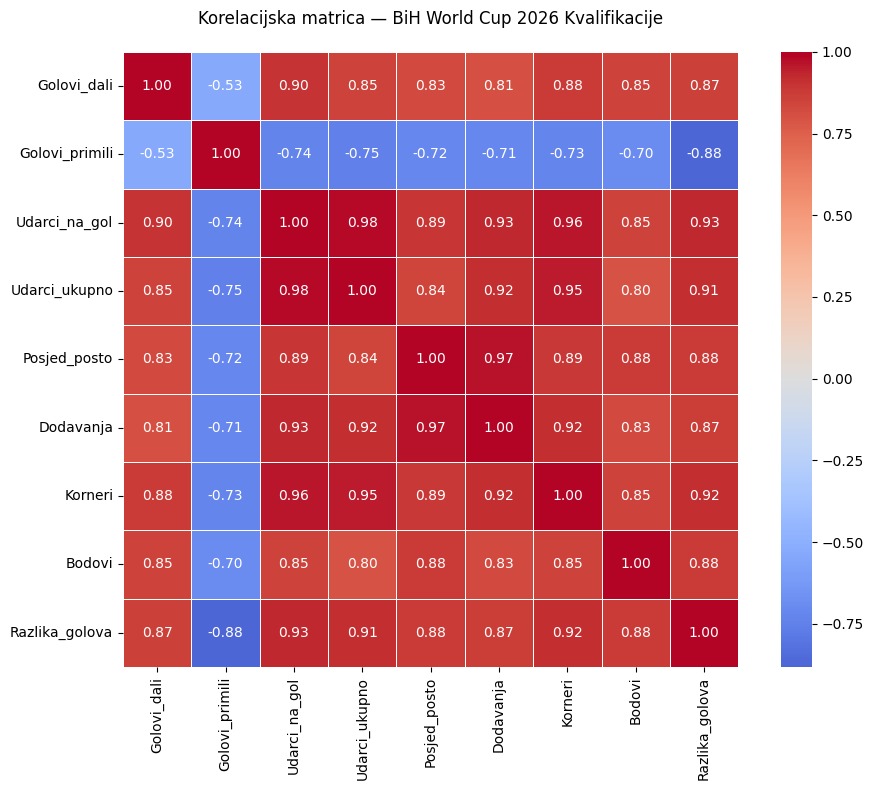


Heatmap sačuvan!


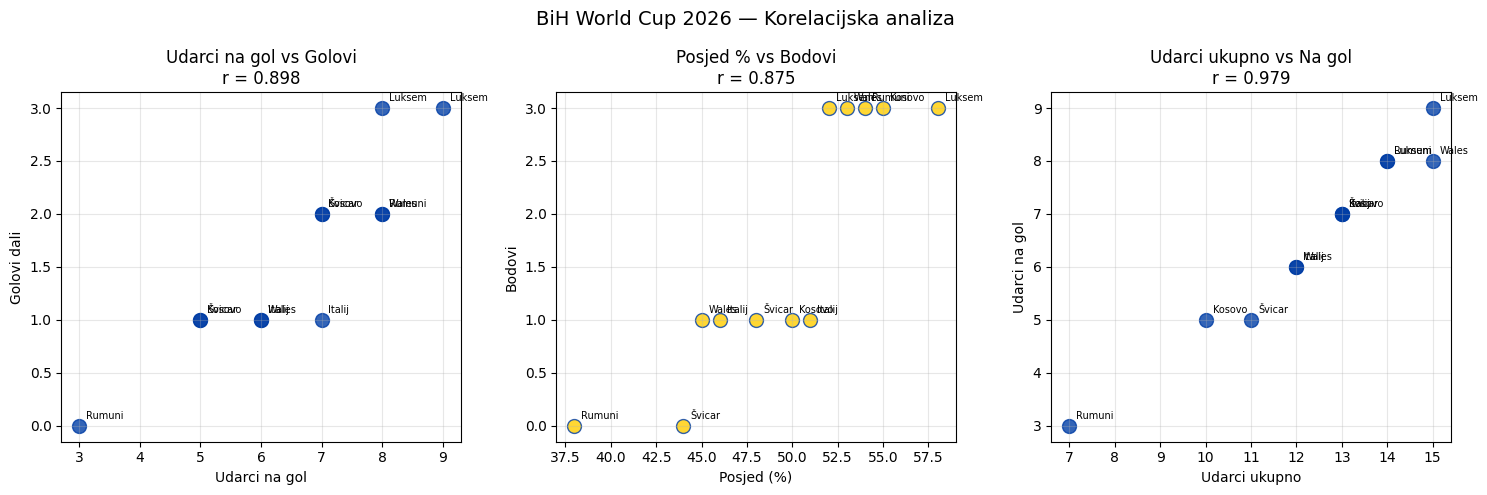

Scatter plotovi sačuvani!

=== LINEARNA REGRESIJA ===
Pitanje: Možemo li predvidjeti broj golova iz udaraca na gol?

Jednadžba: Golovi = 0.482 × Udarci_na_gol + (-1.593)
R² = 0.807
p-vrijednost = 0.0001

Tumačenje R²: Model objašnjava 80.7% varijance u golovima

=== PREDIKCIJA ===
Ako BiH ima 4 udarca na gol → predviđeni golovi: 0.3
Ako BiH ima 6 udarca na gol → predviđeni golovi: 1.3
Ako BiH ima 8 udarca na gol → predviđeni golovi: 2.3
Ako BiH ima 10 udarca na gol → predviđeni golovi: 3.2


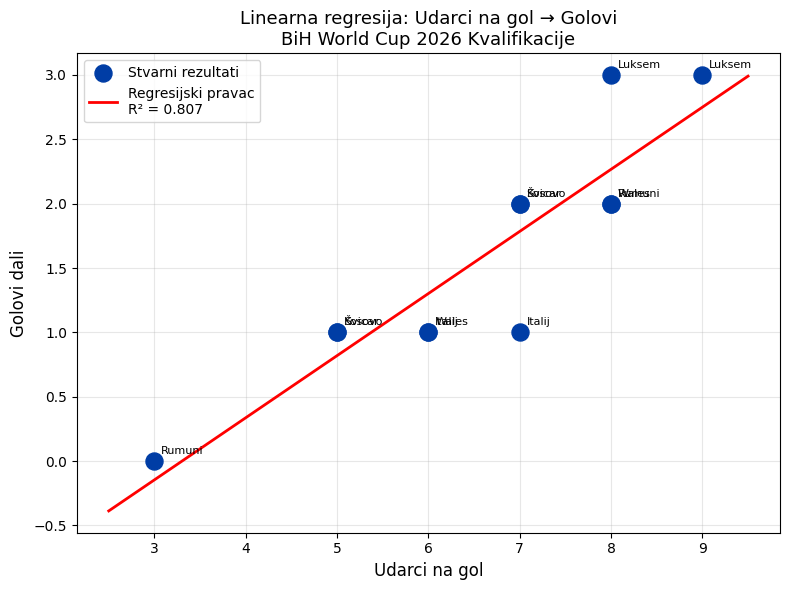


Regresijski plot sačuvan!

=== PEARSONOV KOEFICIJENT ===
Udarci_na_gol vs Golovi_dali: r = 0.898 → Vrlo jaka pozitivna korelacija
Posjed_posto vs Bodovi: r = 0.875 → Vrlo jaka pozitivna korelacija
Dodavanja vs Posjed_posto: r = 0.970 → Vrlo jaka pozitivna korelacija
Korneri vs Golovi_dali: r = 0.880 → Vrlo jaka pozitivna korelacija
Golovi_primili vs Bodovi: r = -0.697 → Jaka negativna korelacija


In [2]:
# ============================================
# LAB: KORELACIJSKA I REGRESIJSKA ANALIZA
# Uvod u analizu podataka
# Dataset: BiH World Cup 2026 Kvalifikacije
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================
# KORAK 1: Učitavanje podataka
# ============================================

data = {
    'Protivnik': ['Luksemburg', 'Rumunija', 'Kosovo', 'Švicarska', 'Luksemburg',
                  'Kosovo', 'Rumunija', 'Švicarska', 'Wales', 'Wales',
                  'Italija', 'Italija'],
    'Golovi_dali': [3, 0, 2, 1, 3, 1, 2, 2, 1, 2, 1, 1],
    'Golovi_primili': [0, 3, 1, 2, 1, 1, 0, 2, 1, 0, 0, 1],
    'Udarci_na_gol': [8, 3, 7, 5, 9, 5, 8, 7, 6, 8, 7, 6],
    'Udarci_ukupno': [14, 7, 13, 11, 15, 10, 14, 13, 12, 15, 13, 12],
    'Posjed_posto': [52, 38, 55, 44, 58, 50, 54, 48, 45, 53, 51, 46],
    'Dodavanja': [412, 298, 445, 367, 478, 389, 432, 401, 378, 445, 423, 389],
    'Korneri': [6, 2, 5, 4, 7, 4, 6, 5, 4, 7, 5, 4],
    'Bodovi': [3, 0, 3, 0, 3, 1, 3, 1, 1, 3, 1, 1]
}

df = pd.DataFrame(data)
df['Razlika_golova'] = df['Golovi_dali'] - df['Golovi_primili']

print("=== DATASET: BiH World Cup 2026 Kvalifikacije ===")
print(df.to_string())
print(f"\nBroj utakmica: {len(df)}")
print(f"Ukupno golova: {df['Golovi_dali'].sum()}")
print(f"Ukupno bodova: {df['Bodovi'].sum()}")

# ============================================
# KORAK 2: Deskriptivna statistika
# ============================================

print("\n=== DESKRIPTIVNA STATISTIKA ===")
print(df[['Golovi_dali', 'Udarci_na_gol', 'Posjed_posto', 'Bodovi']].describe())

# ============================================
# KORAK 3: Korelacijska matrica
# ============================================

print("\n=== KORELACIJSKA MATRICA ===")
korelacije = df[['Golovi_dali', 'Golovi_primili', 'Udarci_na_gol',
                  'Udarci_ukupno', 'Posjed_posto', 'Dodavanja',
                  'Korneri', 'Bodovi', 'Razlika_golova']].corr()
print(korelacije.round(3))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(korelacije, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Korelacijska matrica — BiH World Cup 2026 Kvalifikacije', pad=20)
plt.tight_layout()
plt.show()
print("\nHeatmap sačuvan!")

# ============================================
# KORAK 4: Scatter plotovi
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('BiH World Cup 2026 — Korelacijska analiza', fontsize=14)

# Plot 1: Udarci na gol vs Golovi dali
axes[0].scatter(df['Udarci_na_gol'], df['Golovi_dali'],
                color='#003DA5', s=100, alpha=0.8)
for i, row in df.iterrows():
    axes[0].annotate(row['Protivnik'][:6],
                     (row['Udarci_na_gol'], row['Golovi_dali']),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
axes[0].set_xlabel('Udarci na gol')
axes[0].set_ylabel('Golovi dali')
axes[0].set_title(f'Udarci na gol vs Golovi\nr = {df["Udarci_na_gol"].corr(df["Golovi_dali"]):.3f}')
axes[0].grid(True, alpha=0.3)

# Plot 2: Posjed % vs Bodovi
axes[1].scatter(df['Posjed_posto'], df['Bodovi'],
                color='#FFCD00', s=100, alpha=0.8, edgecolors='#003DA5')
for i, row in df.iterrows():
    axes[1].annotate(row['Protivnik'][:6],
                     (row['Posjed_posto'], row['Bodovi']),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
axes[1].set_xlabel('Posjed (%)')
axes[1].set_ylabel('Bodovi')
axes[1].set_title(f'Posjed % vs Bodovi\nr = {df["Posjed_posto"].corr(df["Bodovi"]):.3f}')
axes[1].grid(True, alpha=0.3)

# Plot 3: Udarci ukupno vs Udarci na gol
axes[2].scatter(df['Udarci_ukupno'], df['Udarci_na_gol'],
                color='#003DA5', s=100, alpha=0.8)
for i, row in df.iterrows():
    axes[2].annotate(row['Protivnik'][:6],
                     (row['Udarci_ukupno'], row['Udarci_na_gol']),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
axes[2].set_xlabel('Udarci ukupno')
axes[2].set_ylabel('Udarci na gol')
axes[2].set_title(f'Udarci ukupno vs Na gol\nr = {df["Udarci_ukupno"].corr(df["Udarci_na_gol"]):.3f}')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Scatter plotovi sačuvani!")

# ============================================
# KORAK 5: Linearna regresija
# ============================================

print("\n=== LINEARNA REGRESIJA ===")
print("Pitanje: Možemo li predvidjeti broj golova iz udaraca na gol?")

x = df['Udarci_na_gol']
y = df['Golovi_dali']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"\nJednadžba: Golovi = {slope:.3f} × Udarci_na_gol + ({intercept:.3f})")
print(f"R² = {r_value**2:.3f}")
print(f"p-vrijednost = {p_value:.4f}")
print(f"\nTumačenje R²: Model objašnjava {r_value**2*100:.1f}% varijance u golovima")

# Predikcija
print("\n=== PREDIKCIJA ===")
test_udarci = [4, 6, 8, 10]
for u in test_udarci:
    gol = slope * u + intercept
    print(f"Ako BiH ima {u} udarca na gol → predviđeni golovi: {gol:.1f}")

# Regresijski plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='#003DA5', s=150, zorder=5, label='Stvarni rezultati')
x_line = np.linspace(x.min()-0.5, x.max()+0.5, 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linewidth=2,
         label=f'Regresijski pravac\nR² = {r_value**2:.3f}')
for i, row in df.iterrows():
    plt.annotate(row['Protivnik'][:6], (row['Udarci_na_gol'], row['Golovi_dali']),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.xlabel('Udarci na gol', fontsize=12)
plt.ylabel('Golovi dali', fontsize=12)
plt.title('Linearna regresija: Udarci na gol → Golovi\nBiH World Cup 2026 Kvalifikacije', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\nRegresijski plot sačuvan!")

# ============================================
# KORAK 6: Pearsonov koeficijent
# ============================================

print("\n=== PEARSONOV KOEFICIJENT ===")
parovi = [
    ('Udarci_na_gol', 'Golovi_dali'),
    ('Posjed_posto', 'Bodovi'),
    ('Dodavanja', 'Posjed_posto'),
    ('Korneri', 'Golovi_dali'),
    ('Golovi_primili', 'Bodovi'),
]

for x_col, y_col in parovi:
    r, p = stats.pearsonr(df[x_col], df[y_col])
    snaga = "Vrlo jaka" if abs(r) > 0.8 else "Jaka" if abs(r) > 0.6 else "Umjerena" if abs(r) > 0.4 else "Slaba"
    smjer = "pozitivna" if r > 0 else "negativna"
    print(f"{x_col} vs {y_col}: r = {r:.3f} → {snaga} {smjer} korelacija")